In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/cleaned/wastewise_cleaned.csv')

print("Data loaded!")
print("Shape:", df.shape)
print(df.head())

Matplotlib is building the font cache; this may take a moment.


Data loaded!
Shape: (1080, 9)
         date          area waste_type  quantity_kg collection_done  \
0  2025-01-01  Arera Colony        Wet        61.25              No   
1  2025-01-01      Shahpura        Dry       112.79             Yes   
2  2025-01-01      TT Nagar        Wet       315.72             Yes   
3  2025-01-01    Kolar Road        Wet       148.39             Yes   
4  2025-01-01     Bairagarh        Dry       372.21              No   

   complaints    month day_of_week  month_num  
0           3  January   Wednesday          1  
1          10  January   Wednesday          1  
2           0  January   Wednesday          1  
3           8  January   Wednesday          1  
4           3  January   Wednesday          1  


C:\Users\Hp\AppData\Local\Temp\ipykernel_17668\158436865.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_waste.index,y=area_waste.values,palette='viridis')


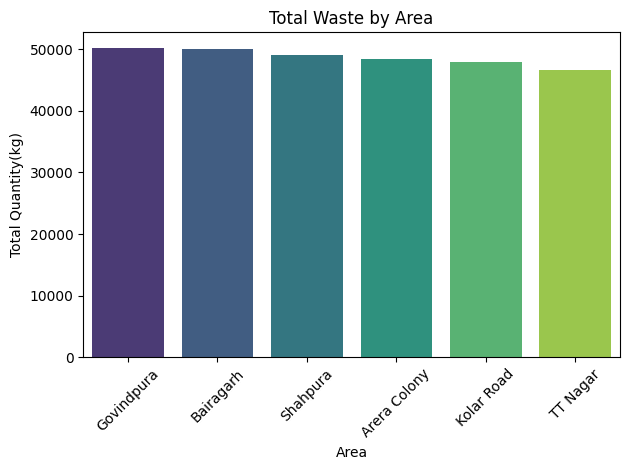

area
Govindpura      50228.62
Bairagarh       50039.82
Shahpura        48984.77
Arera Colony    48389.50
Kolar Road      47934.85
TT Nagar        46680.07
Name: quantity_kg, dtype: float64


In [2]:
# Graph 1: Total waste by area
plt.Figure(figsize=(10,5))
area_waste = df.groupby('area')['quantity_kg'].sum().sort_values(ascending=False)
sns.barplot(x=area_waste.index,y=area_waste.values,palette='viridis')
plt.title('Total Waste by Area')
plt.xlabel('Area')
plt.ylabel('Total Quantity(kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/01_waste_by_area.png')
plt.show()
print(area_waste)

C:\Users\Hp\AppData\Local\Temp\ipykernel_17668\3124265689.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=waste_dist.index, y=waste_dist.values, palette='Set2')


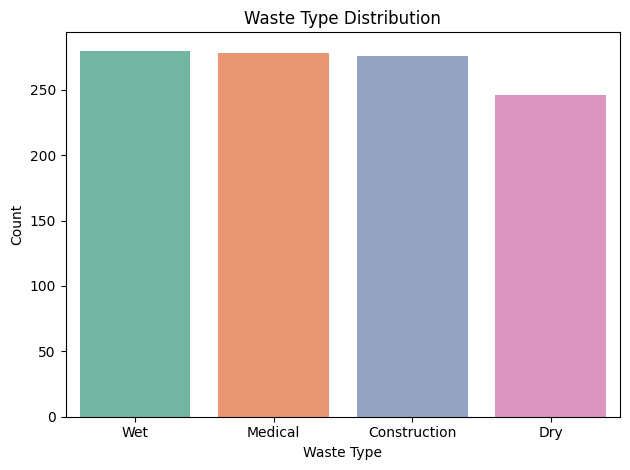

waste_type
Wet             280
Medical         278
Construction    276
Dry             246
Name: count, dtype: int64


In [3]:
# Graph 2: Waste type distribution
plt.Figure(figsize=(8,5))
waste_dist = df['waste_type'].value_counts()
sns.barplot(x=waste_dist.index, y=waste_dist.values, palette='Set2')
plt.title('Waste Type Distribution')
plt.xlabel('Waste Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../dashboard/02_waste_type.png')
plt.show()
print(waste_dist)

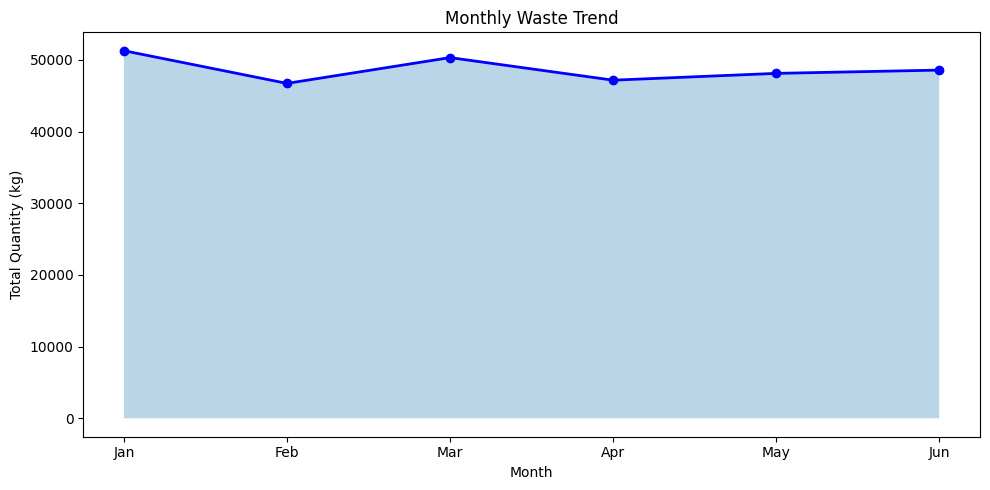

month_num
1    51292.58
2    46733.57
3    50332.27
4    47180.68
5    48131.20
6    48587.33
Name: quantity_kg, dtype: float64


In [4]:
# Graph 3: Monthly waste trend
plt.figure(figsize=(10, 5))
monthly = df.groupby('month_num')['quantity_kg'].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
plt.plot(month_names, monthly.values, marker='o', color='blue', linewidth=2)
plt.fill_between(month_names, monthly.values, alpha=0.3)
plt.title('Monthly Waste Trend')
plt.xlabel('Month')
plt.ylabel('Total Quantity (kg)')
plt.tight_layout()
plt.savefig('../dashboard/03_monthly_trend.png')
plt.show()
print(monthly)

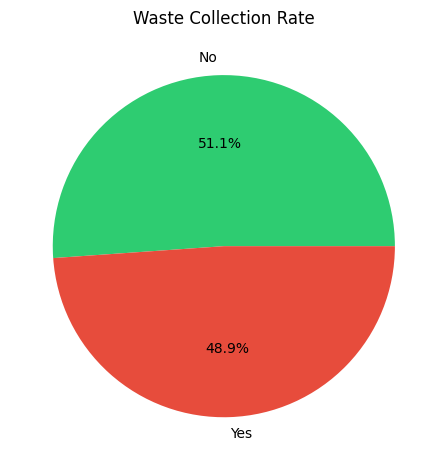

collection_done
No     552
Yes    528
Name: count, dtype: int64


In [6]:
# Graph 4: collection done vs not done
plt.Figure(figsize=(7,5))
collection = df['collection_done'].value_counts()
plt.pie(collection.values, labels=collection.index, autopct='%1.1f%%',colors=['#2ecc71','#e74c3c'])
plt.title('Waste Collection Rate')
plt.tight_layout()
plt.savefig('../dashboard/04_collection_rate.png')
plt.show()
print(collection)